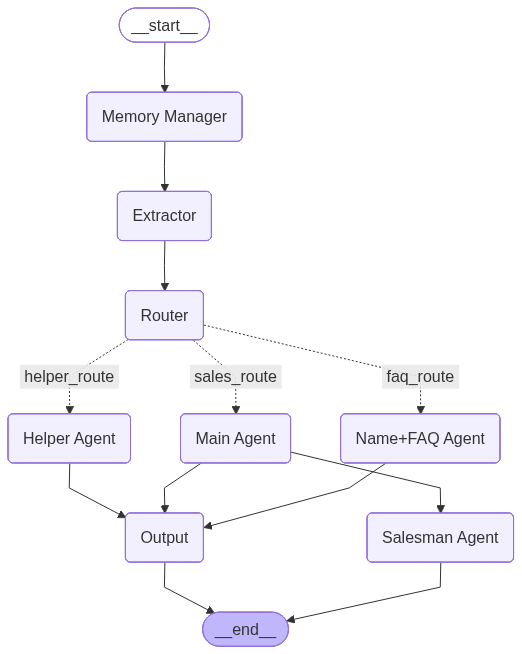

In [2]:
from typing import TypedDict
class AgentState(TypedDict, total=False):
    name: str
    WatchName: str
    Budget: float
    Type: str
    message: str


# ---------------------------------------------------------
# Define dummy agent functions
# ---------------------------------------------------------
def extractor(state: AgentState):
    state["message"] = "Extracted user info: name, WatchName, Budget..."
    return state


def name_faq_agent(state: AgentState):
    state["message"] = "Handled FAQ and name-related queries."
    return state

# !pip install -U langgraph langchain ipython graphviz

from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image
from typing import TypedDict

# ---------------------------------------------------------
# Define shared state schema
# -----------------------------------------------
def helper_agent(state: AgentState):
    state["message"] = "Aggregated supporting information."
    return state


def salesman_agent(state: AgentState):
    state["message"] = "Prepared sales communication."
    return state


def main_agent(state: AgentState):
    state["message"] = "Main Agent coordinating between agents."
    return state


def output_node(state: AgentState):
    state["message"] = f"Output ready: {state.get('message', '')}"
    return state

def memory_manager(state: AgentState):
    state["message"] = f"Output ready: {state.get('message', '')}"
    return state

# ---------------------------------------------------------
# Conditional routing logic (NEW)
# ---------------------------------------------------------
def main_router(state: AgentState) -> str:
    """
    Route logic after Extractor:
    Choose which agent to activate next based on the Type.
    """
    user_type = state.get("Type", "").lower()
    if "faq" in user_type:
        return "faq_route"
    elif "help" in user_type:
        return "helper_route"
    else:
        return "sales_route"


# ---------------------------------------------------------
# Build graph
# ---------------------------------------------------------
graph = StateGraph(AgentState)

# Define nodes
graph.add_node("Extractor", extractor)
graph.add_node("Main Agent", main_agent)
graph.add_node("Router", lambda state: state) 
graph.add_node("Name+FAQ Agent", name_faq_agent)
graph.add_node("Helper Agent", helper_agent)
graph.add_node("Salesman Agent", salesman_agent)
graph.add_node("Output", output_node)
graph.add_node("Memory Manager", memory_manager)

# Define entry
graph.add_edge(START, "Memory Manager")
graph.add_edge( "Memory Manager", "Extractor")

# Extractor goes to Main Agent
graph.add_edge("Extractor", "Router")


# Conditional routing logic
graph.add_conditional_edges(
    "Router",
    main_router,
    {
        "faq_route": "Name+FAQ Agent",
        "helper_route": "Helper Agent",
        "sales_route": "Main Agent",
    },
)

# All agents lead to Output
graph.add_edge("Main Agent", "Salesman Agent")
graph.add_edge("Name+FAQ Agent", "Output")
graph.add_edge("Helper Agent", "Output")
graph.add_edge("Main Agent", "Output")

# Define end of flow
graph.add_edge("Output", END)

# ---------------------------------------------------------
# Compile and visualize
# ---------------------------------------------------------
compiled_graph = graph.compile()

# Display as image
img_path = compiled_graph.get_graph().draw_mermaid_png()
display(Image(img_path))


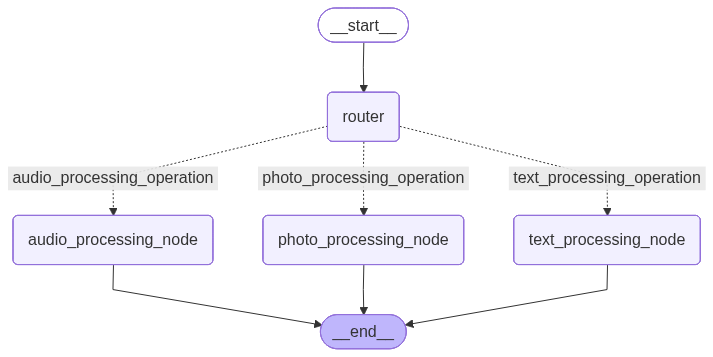

In [14]:
# !pip install -U langgraph langchain ipython graphviz

import base64
import sys
from pathlib import Path
from IPython.display import display, Image
from langgraph.graph import START, END, StateGraph
from langchain_community.chat_models.openai import ChatOpenAI
from langchain_classic.schema import HumanMessage

# -------------------------------------------------------------------
# Dummy placeholders for external project imports
# (Replace these with your real ones if available)
# -------------------------------------------------------------------
class PreProcessingAgentState(dict):
    """Simplified placeholder for visualization"""
    pass

class Lead:
    def __init__(self, message="", type="", user="", image=None, audio=None):
        self.message = message
        self.type = type
        self.user = user
        self.image = image
        self.audio = audio

image_OCR_prompt = "Please extract text from the provided image."

# -------------------------------------------------------------------
# Define node functions
# -------------------------------------------------------------------
def text_processing(state: PreProcessingAgentState) -> PreProcessingAgentState:
    """Handle text pre-processing"""
    state["message"] = "Text processed"
    return state

def photo_processing(state: PreProcessingAgentState) -> PreProcessingAgentState:
    """Handle photo OCR"""
    state["message"] = "Photo processed (OCR done)"
    return state

def audio_processing(state: PreProcessingAgentState) -> PreProcessingAgentState:
    """Handle audio pre-processing"""
    state["message"] = "Audio processed"
    return state

def pre_process_input_cond(state: PreProcessingAgentState) -> str:
    """Router condition based on input type"""
    # Simplified condition logic for visualization
    if state.get("type") == "photo":
        return "photo_processing_operation"
    elif state.get("type") == "audio":
        return "audio_processing_operation"
    else:
        return "text_processing_operation"

# -------------------------------------------------------------------
# Build the graph structure
# -------------------------------------------------------------------
pre_processing_graph = StateGraph(PreProcessingAgentState)

# Add nodes
pre_processing_graph.add_node("text_processing_node", text_processing)
pre_processing_graph.add_node("photo_processing_node", photo_processing)
pre_processing_graph.add_node("audio_processing_node", audio_processing)
pre_processing_graph.add_node("router", lambda state: state)

# Add edges (flow logic)
pre_processing_graph.add_edge(START, "router")

pre_processing_graph.add_conditional_edges(
    "router",
    pre_process_input_cond,
    {
        "text_processing_operation": "text_processing_node",
        "photo_processing_operation": "photo_processing_node",
        "audio_processing_operation": "audio_processing_node"
    },
)

# Define end edges
pre_processing_graph.add_edge("text_processing_node", END)
pre_processing_graph.add_edge("photo_processing_node", END)
pre_processing_graph.add_edge("audio_processing_node", END)

# Compile graph
compiled_graph = pre_processing_graph.compile()

# -------------------------------------------------------------------
# Visualize the Graph
# -------------------------------------------------------------------
# Option 1: Render as PNG (recommended in notebooks)
img_path = compiled_graph.get_graph().draw_mermaid_png()
display(Image(img_path))

# Option 2: (If Graphviz unavailable) Print Mermaid text
# print(compiled_graph.get_graph().draw_mermaid())
